# SAT Crédito — Análisis Exploratorio de Datos (EDA)

**Sistema de Alerta Temprana para Mora en Créditos de Consumo**

Este notebook realiza un análisis exploratorio completo sobre el dataset de créditos de consumo, incluyendo:
- Distribución de las variables de supervivencia (`evento`, `tiempo_evento`) y los targets originales
- Análisis univariado de variables numéricas y categóricas
- Correlaciones entre variables explicativas y el evento de mora
- Análisis bivariado: variables explicativas vs. mora
- Distribución temporal y geográfica
- Indicadores macroeconómicos del BCP

> **Enfoque**: el modelo de scoring usa **Survival Analysis** (Cox PH). El target principal es
> `evento` (1 si incumplió) y `tiempo_evento` (meses hasta el incumplimiento o censura al
> vencimiento del crédito). Los targets `atraso_30/60/90` se conservan como referencia.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

VERDE   = '#2ECC71'
AMARILLO = '#F39C12'
ROJO    = '#E74C3C'
AZUL    = '#2980B9'
GRIS    = '#95A5A6'

In [2]:
# ── Carga de datos ──────────────────────────────────────────────────────────
features = pd.read_csv('../data/processed/features.csv')
alertas  = pd.read_csv('../data/processed/alertas_sat.csv')

print(f'features.csv  → {features.shape[0]:,} filas × {features.shape[1]} columnas')
print(f'alertas_sat.csv → {alertas.shape[0]:,} filas × {alertas.shape[1]} columnas')
features.head(3)

features.csv  → 385,892 filas × 38 columnas
alertas_sat.csv → 385,892 filas × 17 columnas


,id_solicitud,monto_solicitado,cant_cuotas,cuota_mensual_est,ratio_cuota_ingreso,factor_costo_credito,medio,edad,edad_bucket,ingreso,...,delta_tpm_3m,mora_sistema_consumo,spread_mora,ipc_interanual,usd_pyg,periodo_desembolso,nombre_departamento_particular,atraso_30,atraso_60,atraso_90
0,0,1335955.0,24.0,443000.0,0.221500,7.958352,130.0,47,3.0,2000000.0,...,-0.25,5.80,2.80,3.6,7430,2024-01,cordillera,1,0,0
1,1,2243109.0,15.0,334000.0,0.185556,2.233507,96.0,33,1.0,1800000.0,...,0.00,5.35,2.35,3.7,7540,2024-10,concepcion,0,0,0
2,2,5000000.0,12.0,633000.0,0.180857,1.519200,95.0,43,2.0,3500000.0,...,0.00,5.05,2.05,3.5,7570,2025-01,central,1,1,0


---
## 1. Resumen General del Dataset

In [3]:
# Tipos de datos y nulos
info = pd.DataFrame({
    'dtype':    features.dtypes,
    'nulos':    features.isna().sum(),
    'nulos_%':  (features.isna().mean() * 100).round(2),
    'únicos':   features.nunique()
})
print('Columnas con valores nulos:')
display(info[info['nulos'] > 0])
print(f'\nTotal sin nulos: {(info["nulos"] == 0).sum()} / {len(info)} columnas')

Columnas con valores nulos:


,dtype,nulos,nulos_%,únicos
nombre_departamento_particular,object,211,0.05,17



Total sin nulos: 37 / 38 columnas


In [4]:
# Estadísticas descriptivas — variables numéricas clave
cols_desc = ['monto_solicitado', 'cant_cuotas', 'ingreso', 'ratio_cuota_ingreso',
             'promedio_atraso_negofin', 'maximo_atraso_negofin', 'antiguedad_negofin']
features[cols_desc].describe().T.style.format('{:.2f}').background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
monto_solicitado,385892.00,3043483.48,7468732.14,0.00,1358162.00,2000000.00,3500000.00,907230992.00
cant_cuotas,385892.00,12.92,5.13,1.00,10.00,12.00,18.00,94.00
ingreso,385892.00,4714691.90,16932889.79,0.00,2289324.00,2680373.00,4403481.50,2680373000.00
ratio_cuota_ingreso,385892.00,14.38,2655.09,0.00,0.07,0.11,0.17,761000.00
promedio_atraso_negofin,385892.00,46.57,63.61,-1.00,1.24,14.82,81.61,1360.03
maximo_atraso_negofin,385892.00,132.54,127.57,-1.00,21.00,77.00,286.00,3037.00
antiguedad_negofin,385892.00,2.08,6.41,0.00,0.00,1.00,3.00,2021.00


---
## 2. Variables de Supervivencia: `evento` y `tiempo_evento`

El modelo de Survival Analysis requiere dos variables centrales:
- **`evento`**: 1 si el cliente incumplió (`atraso_30 = 1`), 0 si fue censurado al vencimiento
- **`tiempo_evento`**: T=1 mes para incumplidores; T=`cant_cuotas` meses para censurados

A continuación se analiza la distribución de ambas variables y los targets originales.

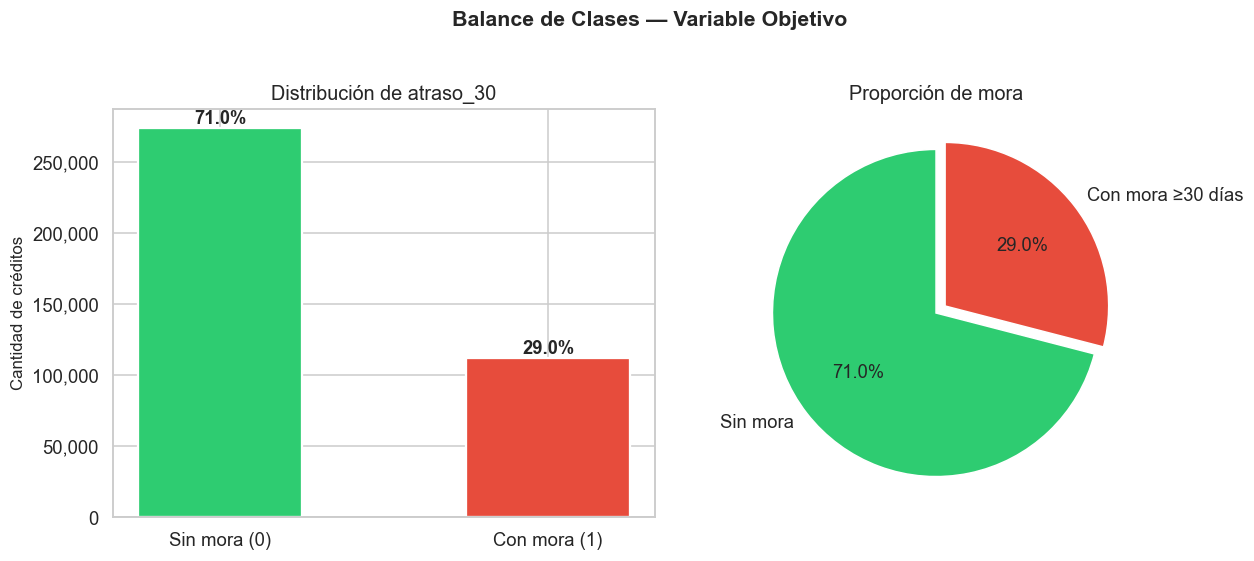

Tasa de mora: 29.0%  |  Ratio desbalance: 1:2.4


In [5]:
# ── Distribución de evento (target survival) ──────────────────────────────
ev_counts = features['evento'].value_counts().sort_index()
ev_pct    = features['evento'].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# — Barras evento —
bars = axes[0].bar(
    ['Censurado (0)', 'Incumplió (1)'],
    ev_counts,
    color=[VERDE, ROJO], edgecolor='white', linewidth=1.5, width=0.5
)
for bar, pct in zip(bars, ev_pct):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
                 f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('evento — Distribución')
axes[0].set_ylabel('Cantidad de créditos')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# — Histograma tiempo_evento censurados —
t_cens = features.loc[features['evento'] == 0, 'tiempo_evento']
axes[1].hist(t_cens, bins=30, color=AZUL, alpha=0.8, edgecolor='white')
axes[1].axvline(t_cens.median(), color='black', linestyle='--', linewidth=1.5,
                label=f'Mediana: {t_cens.median():.0f} m')
axes[1].set_title('tiempo_evento — Censurados (cant_cuotas)')
axes[1].set_xlabel('Meses')
axes[1].set_ylabel('Cantidad')
axes[1].legend()

# — Comparación tres niveles mora (cascada) —
moras = ['atraso_30', 'atraso_60', 'atraso_90']
tasas = [features[m].mean() * 100 for m in moras]
bars3 = axes[2].bar(
    ['Mora ≥30 d\n(evento=1)', 'Mora ≥60 d', 'Mora ≥90 d'],
    tasas,
    color=[AMARILLO, 'darkorange', ROJO], width=0.5, edgecolor='white'
)
for bar, val in zip(bars3, tasas):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[2].set_title('Tasa de mora por nivel (targets originales)')
axes[2].set_ylabel('Tasa (%)')

plt.suptitle('Variables de Supervivencia y Targets Originales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Eventos (incumplió):  {ev_counts[1]:,}  ({ev_pct[1]:.1f}%)')
print(f'Censurados:           {ev_counts[0]:,}  ({ev_pct[0]:.1f}%)')
print(f'T censurados — med: {t_cens.median():.0f} m  |  max: {t_cens.max():.0f} m')

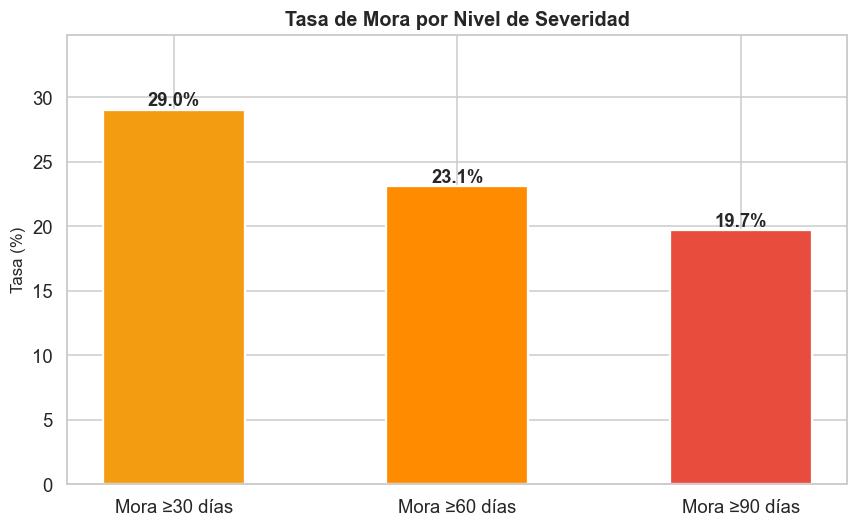

In [6]:
# ── Distribución de tiempo_evento por grupo ────────────────────────────────
# Eventos: todos en T=1 (incumplimiento registrado en el primer mes)
# Censurados: T = cant_cuotas (distribución de plazos del crédito)
t_ev   = features.loc[features['evento'] == 1, 'tiempo_evento']
t_cens = features.loc[features['evento'] == 0, 'tiempo_evento']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de cant_cuotas para censurados vs incumplidores
for ax, val, color, label in [
    (axes[0], 0, AZUL,   'Censurados (evento=0)'),
    (axes[0], 1, ROJO,   'Incumplidores (evento=1)'),
]:
    sub = features[features['evento'] == val]['cant_cuotas']
    ax.hist(sub, bins=20, alpha=0.55, color=color, label=label,
            density=True, edgecolor='none')
axes[0].set_title('Distribución de cant_cuotas por grupo')
axes[0].set_xlabel('cant_cuotas (meses)')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Valores únicos de tiempo_evento de eventos (todos T=1)
axes[1].hist(t_cens.clip(upper=40), bins=25, color=AZUL, alpha=0.75,
             edgecolor='white', label='Censurados')
axes[1].axvline(1, color=ROJO, linewidth=2.5, linestyle='--',
                label=f'Eventos: todos T=1 (n={len(t_ev):,})')
axes[1].set_title('tiempo_evento: censurados y eventos')
axes[1].set_xlabel('tiempo_evento (meses)')
axes[1].set_ylabel('Cantidad')
axes[1].legend()
axes[1].set_xlim([0, 41])

plt.suptitle('Estructura de la Variable de Supervivencia', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Nota: Los targets atraso_30/60/90 son CUMULATIVOS (atraso_60=1 implica atraso_30=1).')
print('Por eso todos los eventos tienen T=1: usamos atraso_30 como evento (first-hitting-time).')
print(f'\ncant_cuotas — incumplidores: media={features[features["evento"]==1]["cant_cuotas"].mean():.1f}  '
      f'censurados: media={features[features["evento"]==0]["cant_cuotas"].mean():.1f}')

---
## 3. Distribución Temporal

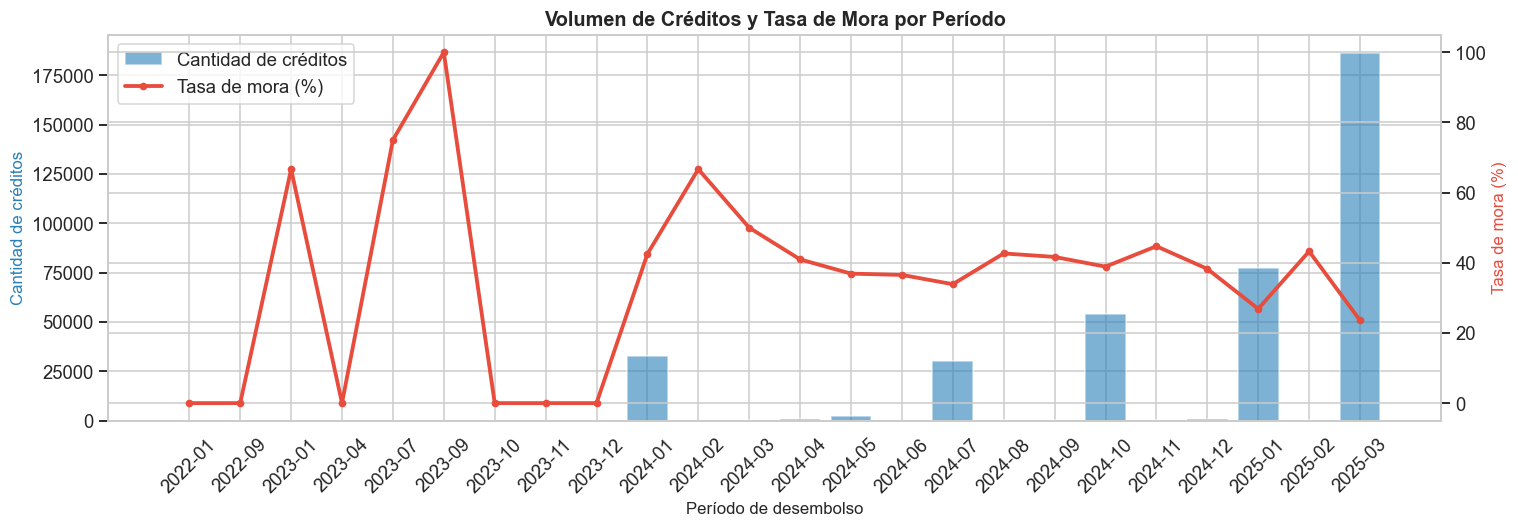

In [7]:
# Créditos y tasa de mora por período de desembolso
features['periodo_dt'] = pd.to_datetime(features['periodo_desembolso'])
temporal = features.groupby('periodo_desembolso').agg(
    total=('atraso_30', 'count'),
    tasa_mora=('atraso_30', 'mean')
).reset_index()
temporal['tasa_mora'] *= 100
temporal = temporal.sort_values('periodo_desembolso')

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(temporal['periodo_desembolso'], temporal['total'],
        color=AZUL, alpha=0.6, label='Cantidad de créditos')
ax2.plot(temporal['periodo_desembolso'], temporal['tasa_mora'],
         color=ROJO, linewidth=2.5, marker='o', markersize=4, label='Tasa de mora (%)')

ax1.set_xlabel('Período de desembolso')
ax1.set_ylabel('Cantidad de créditos', color=AZUL)
ax2.set_ylabel('Tasa de mora (%)', color=ROJO)
ax1.tick_params(axis='x', rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Volumen de Créditos y Tasa de Mora por Período', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 4. Variables de Historial Crediticio

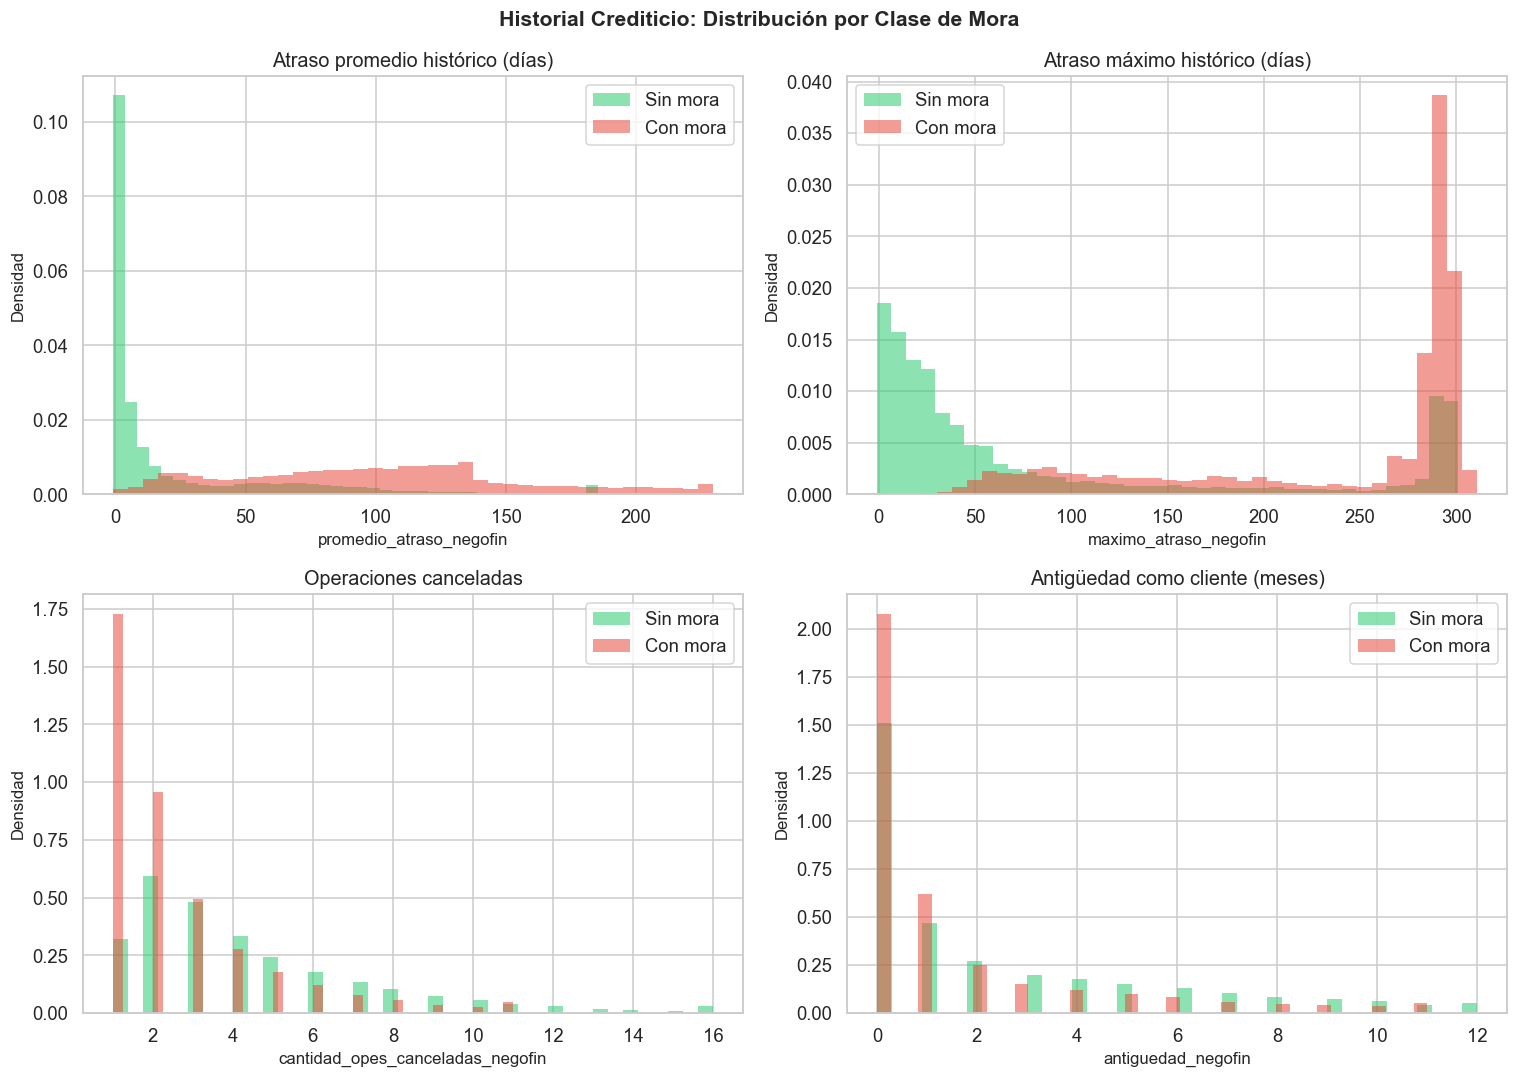

In [8]:
# Distribución de las principales variables de historial — por clase
hist_vars = [
    ('promedio_atraso_negofin', 'Atraso promedio histórico (días)'),
    ('maximo_atraso_negofin',   'Atraso máximo histórico (días)'),
    ('cantidad_opes_canceladas_negofin', 'Operaciones canceladas'),
    ('antiguedad_negofin',      'Antigüedad como cliente (meses)')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (col, label) in zip(axes.flatten(), hist_vars):
    for val, color, nombre in [(0, VERDE, 'Sin mora'), (1, ROJO, 'Con mora')]:
        sub = features[features['atraso_30'] == val][col]
        sub_clip = sub.clip(upper=sub.quantile(0.99))  # recorte para legibilidad
        ax.hist(sub_clip, bins=40, alpha=0.55, color=color,
                label=nombre, density=True, edgecolor='none')
    ax.set_title(label)
    ax.set_xlabel(col)
    ax.set_ylabel('Densidad')
    ax.legend()

plt.suptitle('Historial Crediticio: Distribución por Clase de Mora', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

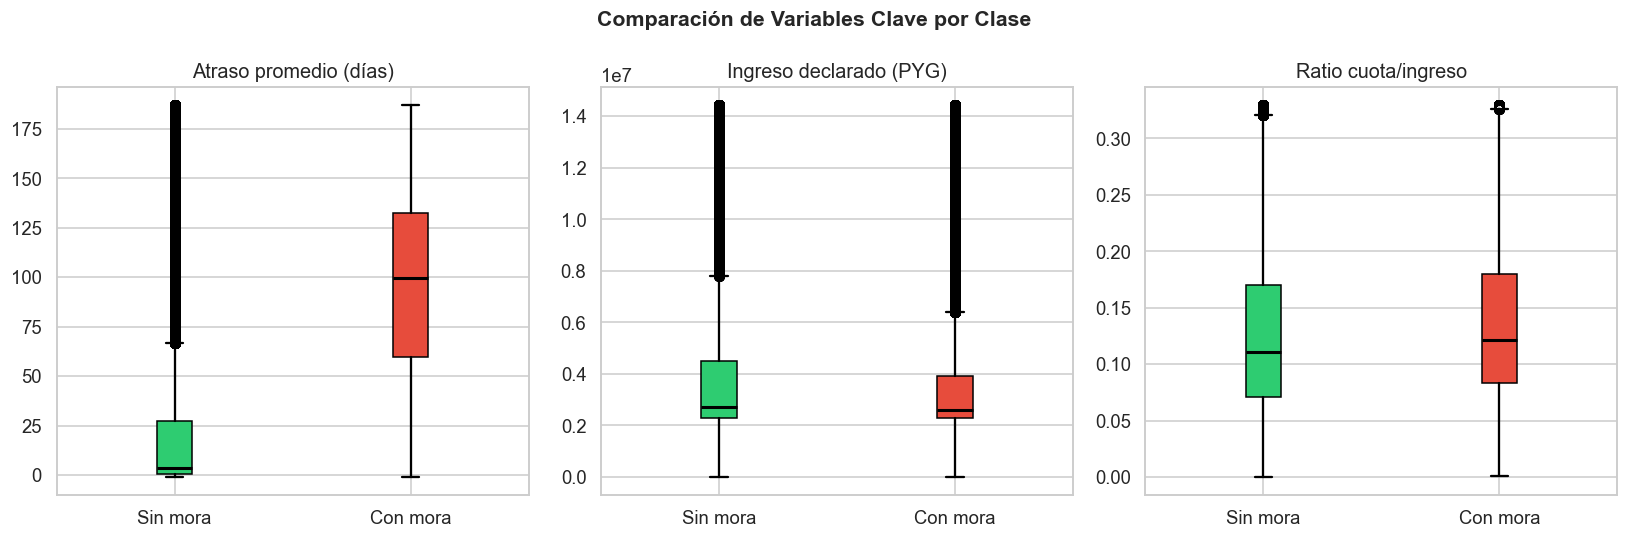

In [9]:
# Boxplots — atraso promedio e ingreso por clase
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

boxplot_vars = [
    ('promedio_atraso_negofin', 'Atraso promedio (días)'),
    ('ingreso',                 'Ingreso declarado (PYG)'),
    ('ratio_cuota_ingreso',     'Ratio cuota/ingreso')
]

for ax, (col, label) in zip(axes, boxplot_vars):
    data_plot = [
        features[features['atraso_30'] == 0][col].clip(upper=features[col].quantile(0.97)),
        features[features['atraso_30'] == 1][col].clip(upper=features[col].quantile(0.97))
    ]
    bp = ax.boxplot(data_plot, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2},
                    whiskerprops={'linewidth': 1.5},
                    capprops={'linewidth': 1.5})
    bp['boxes'][0].set_facecolor(VERDE)
    bp['boxes'][1].set_facecolor(ROJO)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Sin mora', 'Con mora'])
    ax.set_title(label)

plt.suptitle('Comparación de Variables Clave por Clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Variables Financieras del Crédito

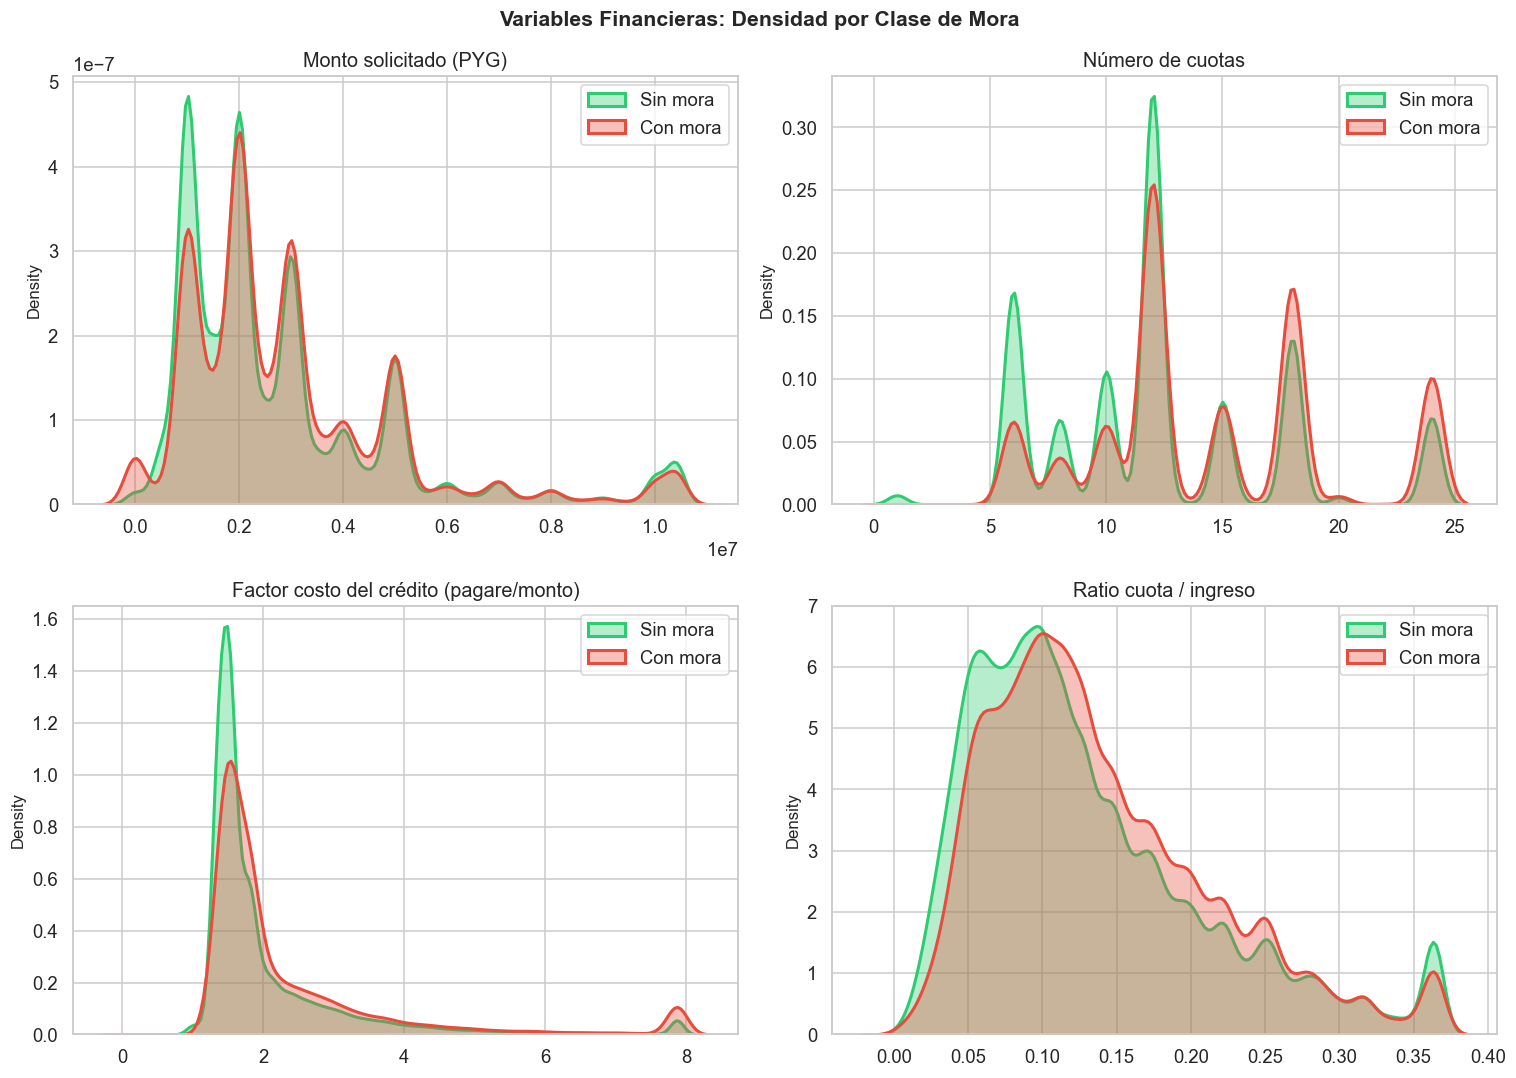

In [10]:
fin_vars = [
    ('monto_solicitado', 'Monto solicitado (PYG)'),
    ('cant_cuotas',      'Número de cuotas'),
    ('factor_costo_credito', 'Factor costo del crédito (pagare/monto)'),
    ('ratio_cuota_ingreso',  'Ratio cuota / ingreso')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (col, label) in zip(axes.flatten(), fin_vars):
    for val, color, nombre in [(0, VERDE, 'Sin mora'), (1, ROJO, 'Con mora')]:
        sub = features[features['atraso_30'] == val][col].clip(upper=features[col].quantile(0.98))
        sns.kdeplot(sub, ax=ax, color=color, label=nombre, fill=True, alpha=0.35, linewidth=2)
    ax.set_title(label)
    ax.set_xlabel('')
    ax.legend()

plt.suptitle('Variables Financieras: Densidad por Clase de Mora', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Variables Categóricas y Binarias

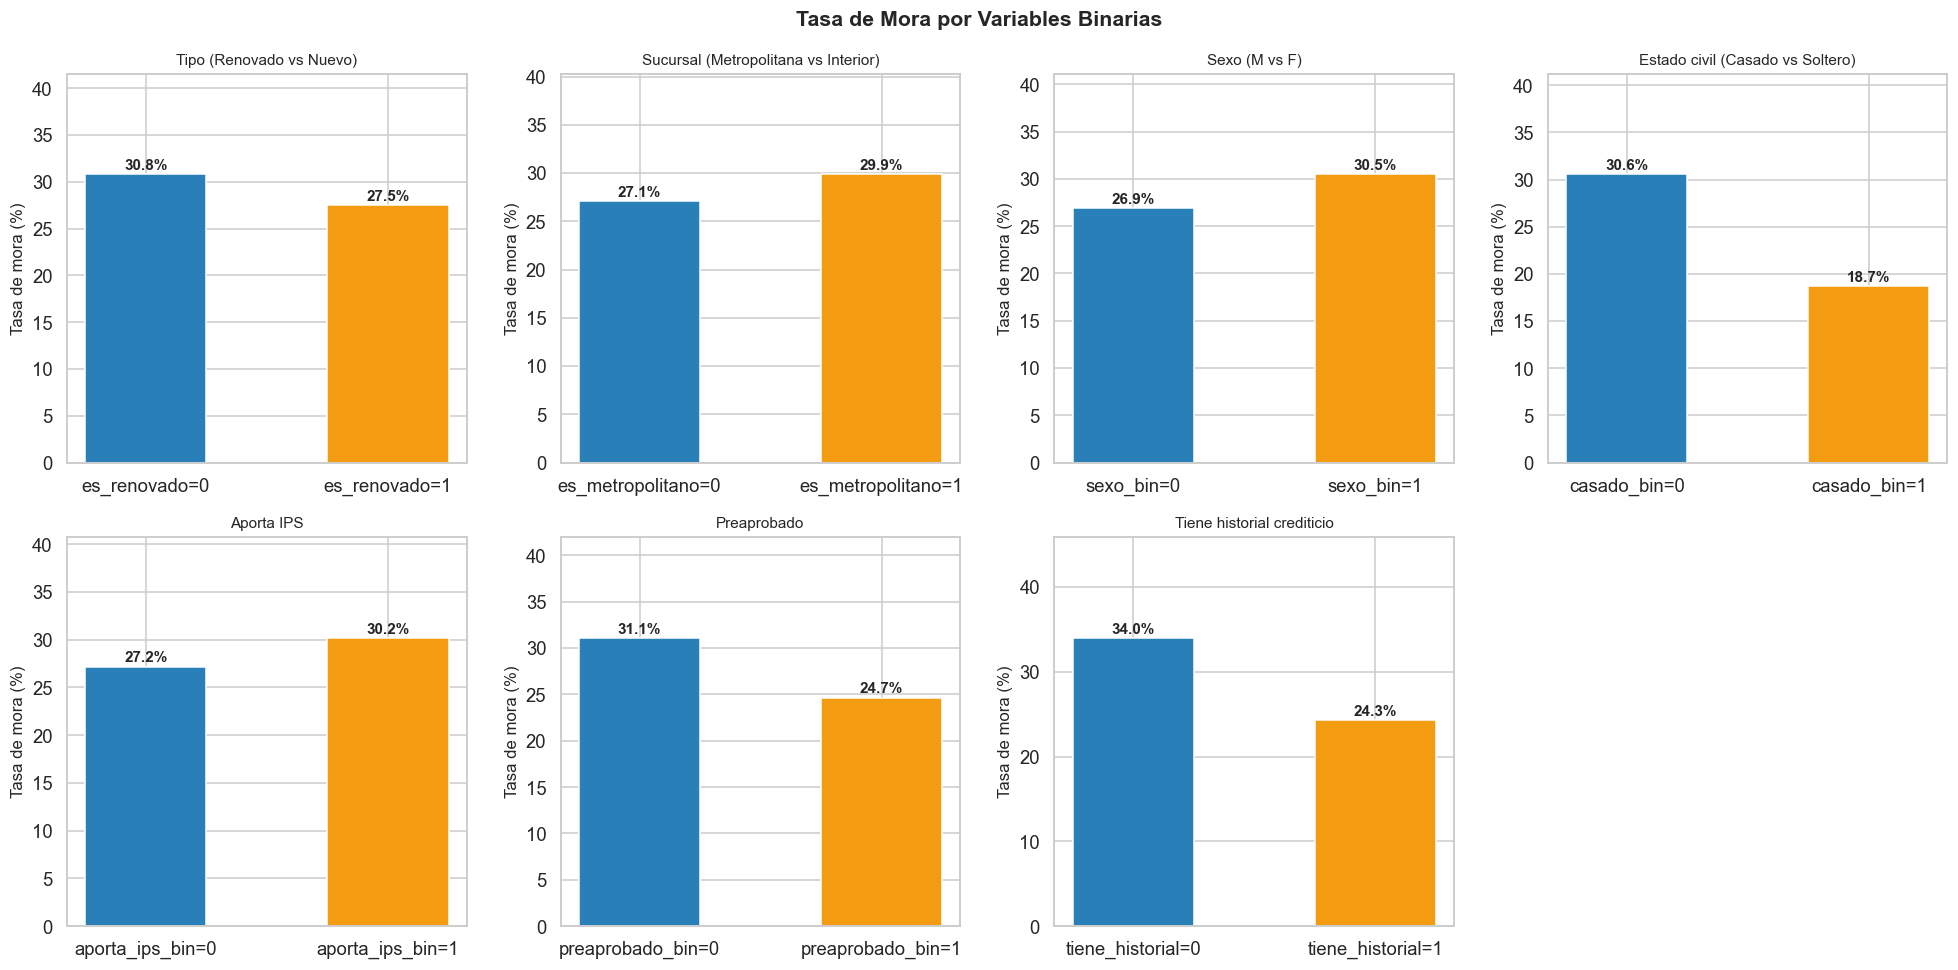

In [11]:
# Tasa de mora por variables binarias
binary_vars = {
    'es_renovado':       'Tipo (Renovado vs Nuevo)',
    'es_metropolitano':  'Sucursal (Metropolitana vs Interior)',
    'sexo_bin':          'Sexo (M vs F)',
    'casado_bin':        'Estado civil (Casado vs Soltero)',
    'aporta_ips_bin':    'Aporta IPS',
    'preaprobado_bin':   'Preaprobado',
    'tiene_historial':   'Tiene historial crediticio'
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, (col, label) in zip(axes, binary_vars.items()):
    tasa = features.groupby(col)['atraso_30'].mean() * 100
    bars = ax.bar(
        [f'{col}=0', f'{col}=1'],
        [tasa.get(0, 0), tasa.get(1, 0)],
        color=[AZUL, AMARILLO], edgecolor='white', width=0.5
    )
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=10)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('Tasa de mora (%)')
    ax.set_ylim(0, max(tasa.get(0, 0), tasa.get(1, 0)) * 1.35)

# Ocultar subplot vacío
axes[-1].set_visible(False)

plt.suptitle('Tasa de Mora por Variables Binarias', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

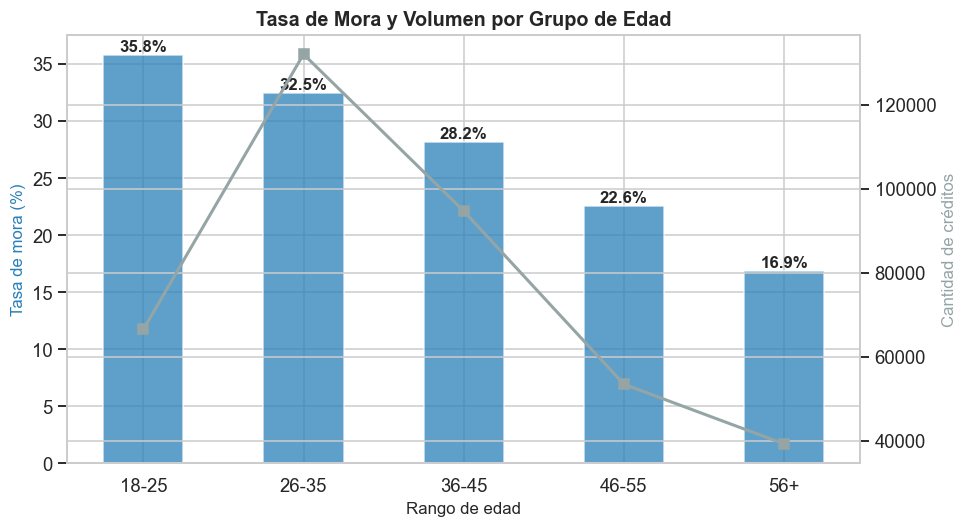

In [12]:
# Tasa de mora por bucket de edad
etiquetas_edad = {0: '18-25', 1: '26-35', 2: '36-45', 3: '46-55', 4: '56+'}
features['edad_label'] = features['edad_bucket'].map(etiquetas_edad)

edad_mora = features.groupby('edad_label')['atraso_30'].agg(['mean', 'count']).reset_index()
edad_mora['mean'] *= 100
edad_mora = edad_mora.sort_values('edad_label')

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

bars = ax1.bar(edad_mora['edad_label'], edad_mora['mean'],
               color=AZUL, alpha=0.75, width=0.5, label='Tasa de mora')
ax2.plot(edad_mora['edad_label'], edad_mora['count'],
         color=GRIS, linewidth=2, marker='s', markersize=7, label='# créditos')

for bar in bars:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=11)

ax1.set_xlabel('Rango de edad')
ax1.set_ylabel('Tasa de mora (%)', color=AZUL)
ax2.set_ylabel('Cantidad de créditos', color=GRIS)
ax1.set_title('Tasa de Mora y Volumen por Grupo de Edad', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Distribución Geográfica

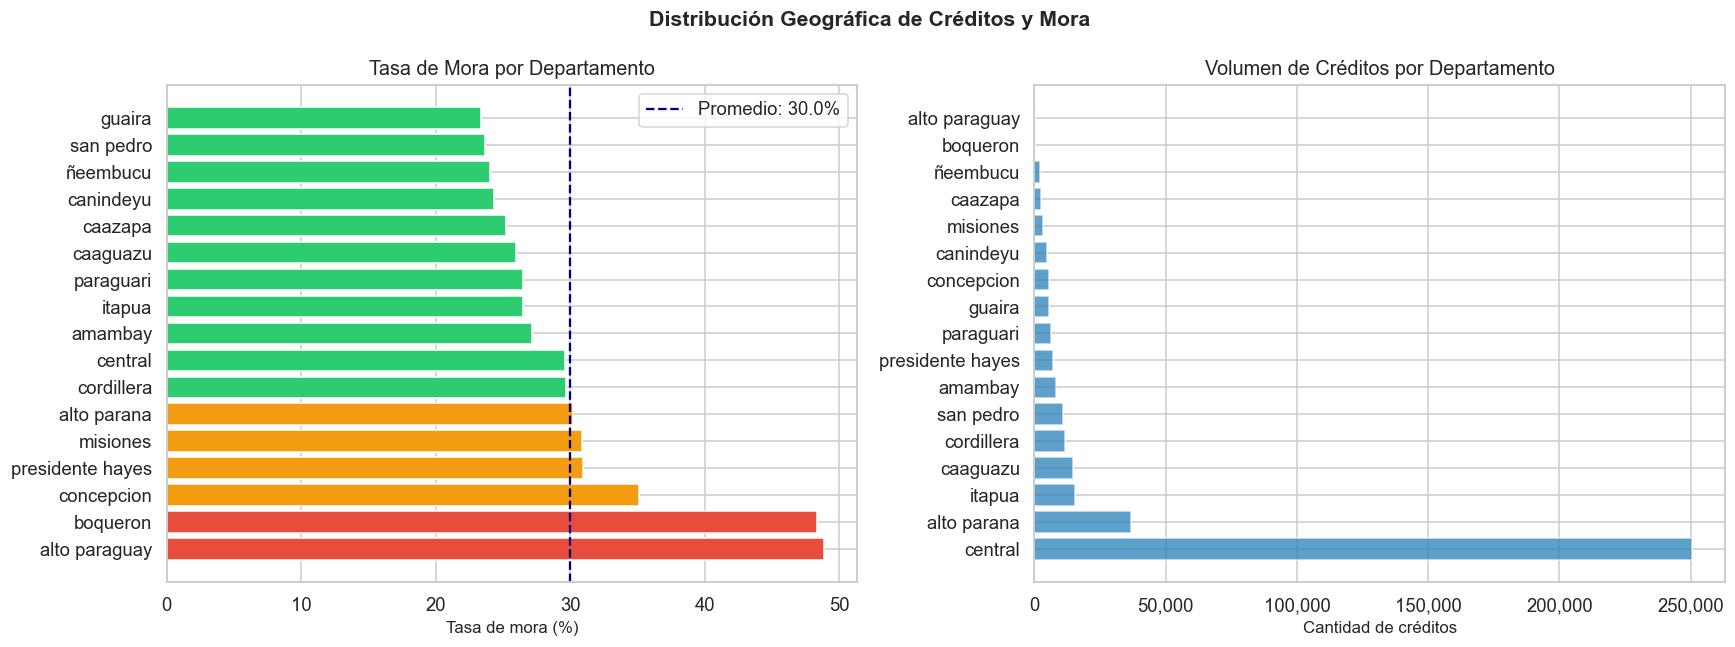

In [13]:
# Tasa de mora y volumen por departamento
geo = features.groupby('nombre_departamento_particular').agg(
    total=('atraso_30', 'count'),
    tasa_mora=('atraso_30', 'mean')
).reset_index()
geo['tasa_mora'] *= 100
geo = geo.sort_values('tasa_mora', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tasa de mora por departamento
colors_geo = [ROJO if t >= 40 else AMARILLO if t >= 30 else VERDE for t in geo['tasa_mora']]
axes[0].barh(geo['nombre_departamento_particular'], geo['tasa_mora'],
             color=colors_geo, edgecolor='white')
axes[0].axvline(geo['tasa_mora'].mean(), color='navy', linestyle='--',
                linewidth=1.5, label=f'Promedio: {geo["tasa_mora"].mean():.1f}%')
axes[0].set_xlabel('Tasa de mora (%)')
axes[0].set_title('Tasa de Mora por Departamento')
axes[0].legend()

# Volumen por departamento
geo_vol = geo.sort_values('total', ascending=False)
axes[1].barh(geo_vol['nombre_departamento_particular'], geo_vol['total'],
             color=AZUL, alpha=0.75, edgecolor='white')
axes[1].set_xlabel('Cantidad de créditos')
axes[1].set_title('Volumen de Créditos por Departamento')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Distribución Geográfica de Créditos y Mora', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Indicadores Macroeconómicos del BCP

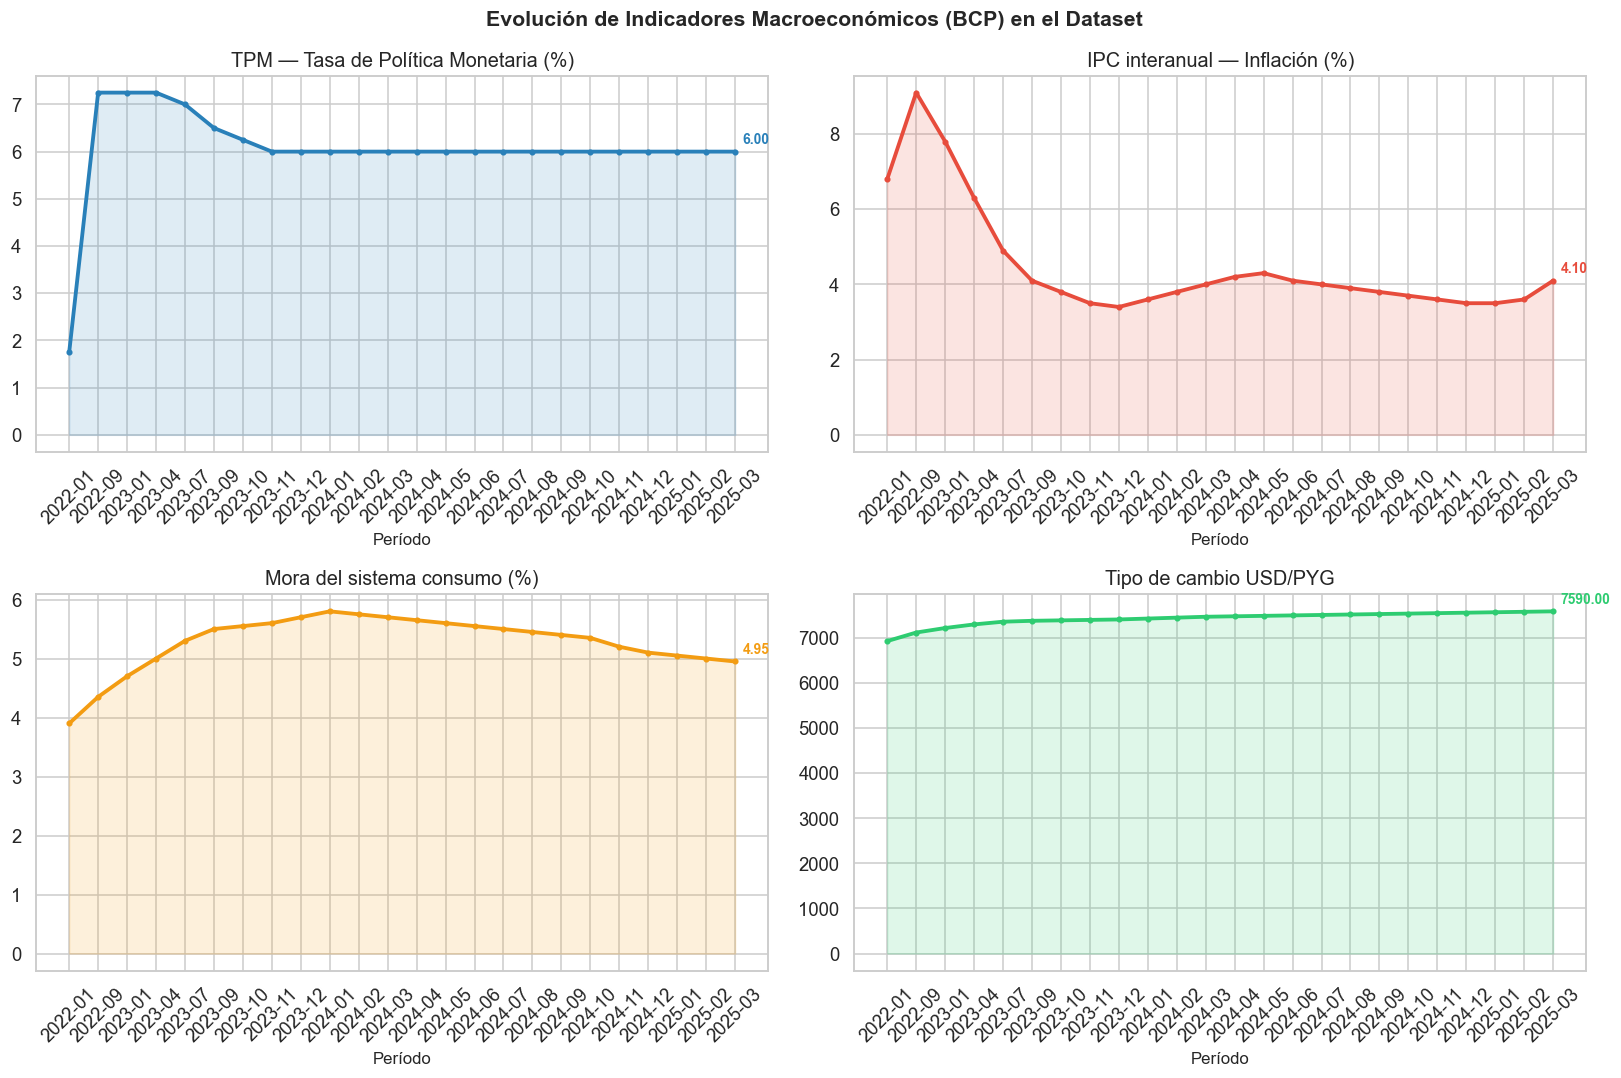

In [14]:
# Evolución de macro indicadores en el dataset
macro_cols = ['tpm', 'ipc_interanual', 'mora_sistema_consumo', 'usd_pyg']
macro_labels = {
    'tpm':                   'TPM — Tasa de Política Monetaria (%)',
    'ipc_interanual':        'IPC interanual — Inflación (%)',
    'mora_sistema_consumo':  'Mora del sistema consumo (%)',
    'usd_pyg':               'Tipo de cambio USD/PYG'
}

macro_ts = features.groupby('periodo_desembolso')[macro_cols].mean().reset_index()
macro_ts = macro_ts.sort_values('periodo_desembolso')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
colores_macro = [AZUL, ROJO, AMARILLO, VERDE]

for ax, col, color in zip(axes.flatten(), macro_cols, colores_macro):
    ax.plot(macro_ts['periodo_desembolso'], macro_ts[col],
            color=color, linewidth=2.5, marker='o', markersize=3)
    ax.fill_between(macro_ts['periodo_desembolso'], macro_ts[col],
                    alpha=0.15, color=color)
    ax.set_title(macro_labels[col])
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('Período')
    # Marcar el último valor
    ultimo = macro_ts.iloc[-1]
    ax.annotate(f"{ultimo[col]:.2f}",
                xy=(ultimo['periodo_desembolso'], ultimo[col]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, color=color, fontweight='bold')

plt.suptitle('Evolución de Indicadores Macroeconómicos (BCP) en el Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

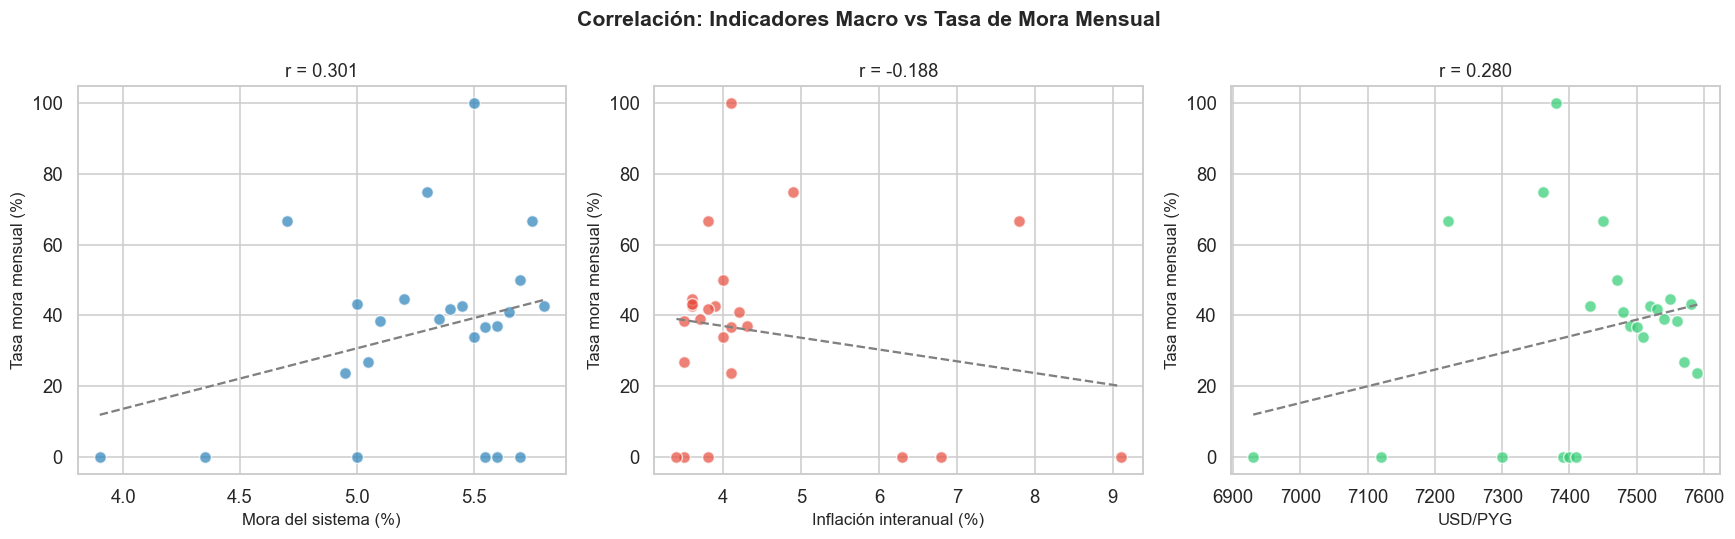

In [15]:
# Correlación entre macro indicadores y tasa de mora mensual
macro_mora = features.groupby('periodo_desembolso').agg(
    tasa_mora=('atraso_30', 'mean'),
    tpm=('tpm', 'mean'),
    ipc=('ipc_interanual', 'mean'),
    mora_sist=('mora_sistema_consumo', 'mean'),
    usd=('usd_pyg', 'mean')
).reset_index()
macro_mora['tasa_mora'] *= 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
scatter_pairs = [
    ('mora_sist', 'Mora del sistema (%)', AZUL),
    ('ipc',       'Inflación interanual (%)', ROJO),
    ('usd',       'USD/PYG', VERDE)
]

for ax, (xcol, xlabel, color) in zip(axes, scatter_pairs):
    ax.scatter(macro_mora[xcol], macro_mora['tasa_mora'],
               color=color, s=60, alpha=0.7, edgecolors='white')
    # Línea de tendencia
    z = np.polyfit(macro_mora[xcol], macro_mora['tasa_mora'], 1)
    p = np.poly1d(z)
    xs = np.linspace(macro_mora[xcol].min(), macro_mora[xcol].max(), 100)
    ax.plot(xs, p(xs), '--', color='gray', linewidth=1.5)
    corr = macro_mora[[xcol, 'tasa_mora']].corr().iloc[0, 1]
    ax.set_title(f'r = {corr:.3f}', fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Tasa mora mensual (%)')

plt.suptitle('Correlación: Indicadores Macro vs Tasa de Mora Mensual',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Matriz de Correlaciones

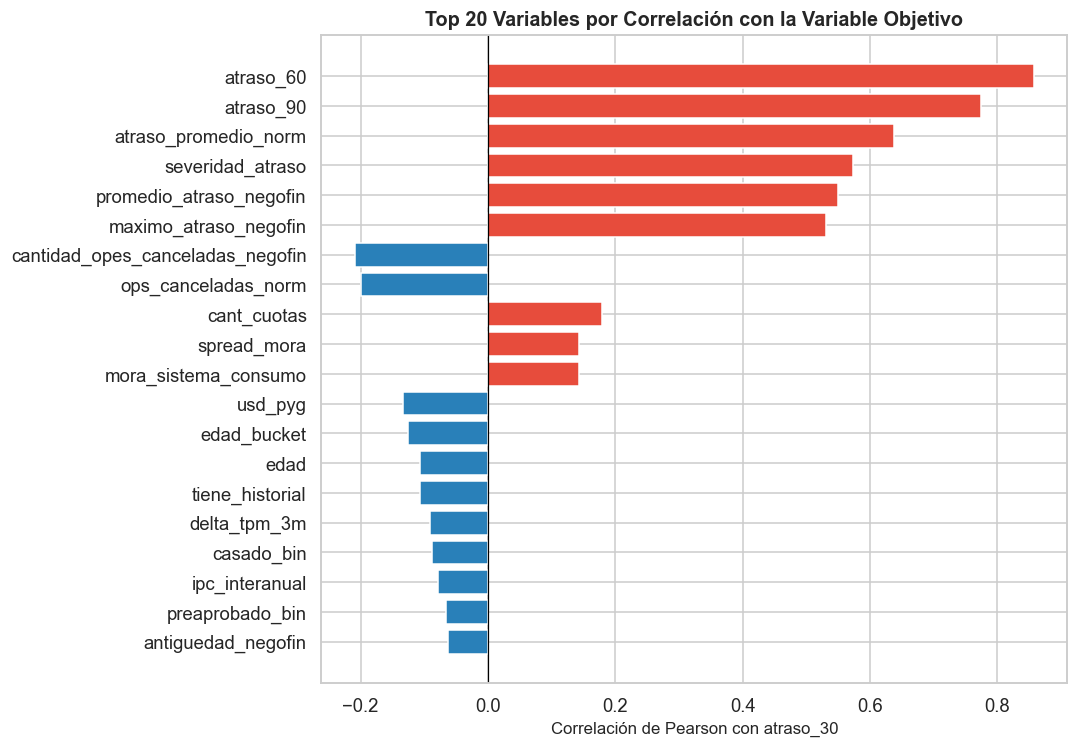

In [16]:
# Correlaciones de las variables numéricas con 'evento' (target survival)
# y con 'atraso_30' (referencia) — deben coincidir pues evento = atraso_30
num_cols = features.select_dtypes(include=[np.number]).columns.tolist()
excluir  = ['atraso_30', 'atraso_60', 'atraso_90', 'evento', 'tiempo_evento']

corr_evento = (
    features[num_cols]
    .corr()['evento']
    .drop(excluir, errors='ignore')
    .sort_values(key=abs, ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 7))
colores_corr = [ROJO if v > 0 else AZUL for v in corr_evento]
ax.barh(corr_evento.index[::-1], corr_evento.values[::-1],
        color=colores_corr[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson con evento (incumplimiento)')
ax.set_title('Top 20 Variables por Correlación con el Evento de Mora\n'
             '(rojo = mayor riesgo, azul = menor riesgo)',
             fontweight='bold')
plt.tight_layout()
plt.show()


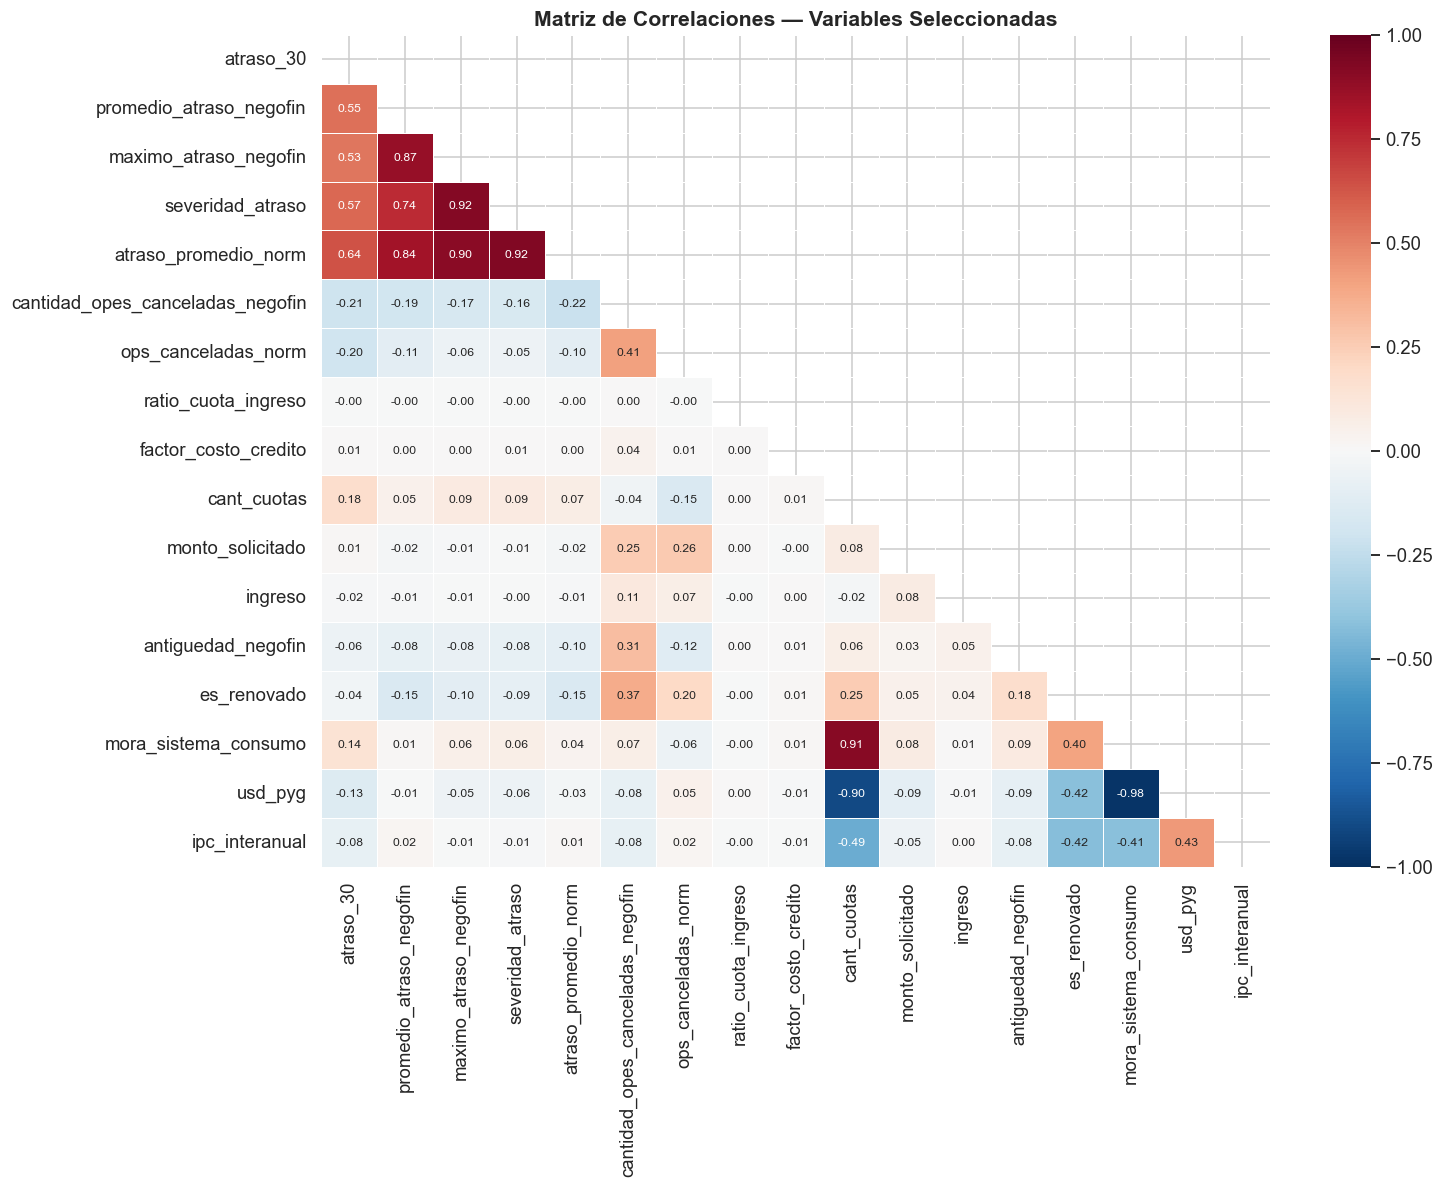

In [17]:
# Heatmap de correlaciones — top variables de historial y financieras
heatmap_cols = [
    'atraso_30',
    'promedio_atraso_negofin', 'maximo_atraso_negofin',
    'severidad_atraso', 'atraso_promedio_norm',
    'cantidad_opes_canceladas_negofin', 'ops_canceladas_norm',
    'ratio_cuota_ingreso', 'factor_costo_credito',
    'cant_cuotas', 'monto_solicitado', 'ingreso',
    'antiguedad_negofin', 'es_renovado',
    'mora_sistema_consumo', 'usd_pyg', 'ipc_interanual'
]

corr_matrix = features[heatmap_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    annot_kws={'size': 8},
    ax=ax
)
ax.set_title('Matriz de Correlaciones — Variables Seleccionadas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Análisis de Segmentos de Riesgo

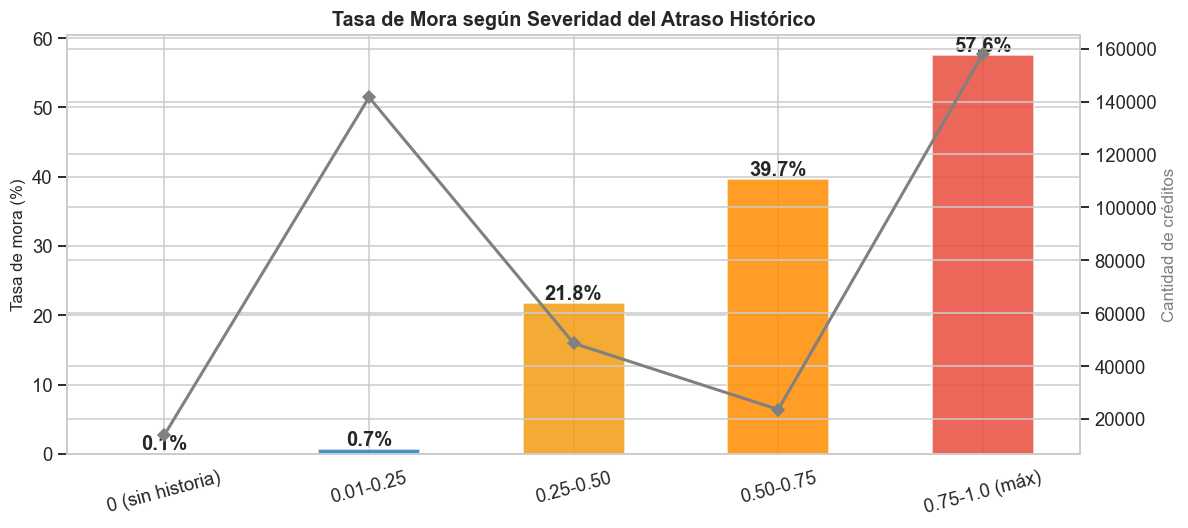

In [18]:
# Severidad del atraso histórico vs tasa de mora actual
features['sev_bucket'] = pd.cut(
    features['severidad_atraso'],
    bins=[-0.01, 0, 0.25, 0.5, 0.75, 1.01],
    labels=['0 (sin historia)', '0.01-0.25', '0.25-0.50', '0.50-0.75', '0.75-1.0 (máx)']
)

sev_mora = features.groupby('sev_bucket', observed=True)['atraso_30'].agg(
    ['mean', 'count']
).reset_index()
sev_mora['mean'] *= 100

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

x = range(len(sev_mora))
bars = ax1.bar(x, sev_mora['mean'], color=[VERDE, AZUL, AMARILLO, 'darkorange', ROJO],
               width=0.5, alpha=0.85, edgecolor='white')
ax2.plot(x, sev_mora['count'], color='gray', linewidth=2, marker='D', markersize=6)

for bar in bars:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', fontweight='bold')

ax1.set_xticks(list(x))
ax1.set_xticklabels(sev_mora['sev_bucket'], rotation=15)
ax1.set_ylabel('Tasa de mora (%)')
ax2.set_ylabel('Cantidad de créditos', color='gray')
ax1.set_title('Tasa de Mora según Severidad del Atraso Histórico', fontweight='bold')
plt.tight_layout()
plt.show()

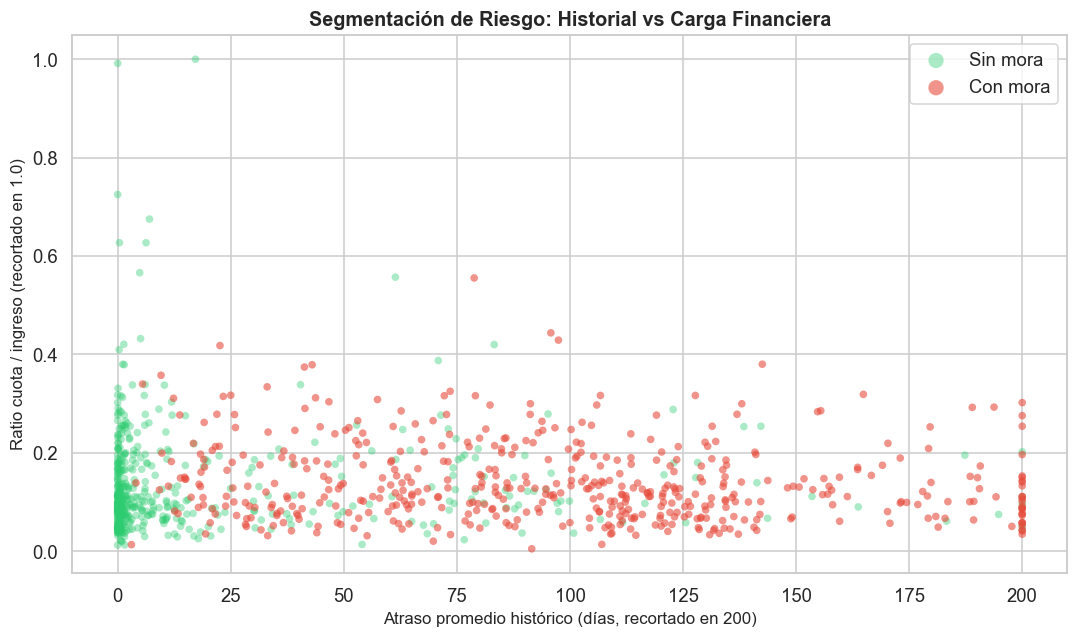

In [19]:
# Scatterplot: atraso promedio vs ratio cuota/ingreso coloreado por mora
fig, ax = plt.subplots(figsize=(10, 6))

for val, color, label, alpha in [(0, VERDE, 'Sin mora', 0.4), (1, ROJO, 'Con mora', 0.6)]:
    sub = features[features['atraso_30'] == val].sample(min(500, (features['atraso_30'] == val).sum()), random_state=42)
    ax.scatter(
        sub['promedio_atraso_negofin'].clip(upper=200),
        sub['ratio_cuota_ingreso'].clip(upper=1.0),
        c=color, label=label, alpha=alpha, s=25, edgecolors='none'
    )

ax.set_xlabel('Atraso promedio histórico (días, recortado en 200)')
ax.set_ylabel('Ratio cuota / ingreso (recortado en 1.0)')
ax.set_title('Segmentación de Riesgo: Historial vs Carga Financiera', fontweight='bold')
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

---
## 11. Resumen del EDA

| Hallazgo | Detalle |
|---|---|
| **Variable de supervivencia** | `evento`=1 en 29% de créditos; `tiempo_evento`=1 (evento) o `cant_cuotas` (censurado, 6–94 meses) |
| **Targets cumulativos** | atraso_60=1 implica atraso_30=1 → todos los eventos ocurren en T=1 |
| **Predictores más fuertes** | Historial de atraso (`promedio`, `máximo`, `severidad`) con correlaciones >0.6 con `evento` |
| **Segmento de mayor riesgo** | Clientes con `severidad_atraso` > 0.75 presentan mora >80% |
| **Plazo del crédito** | `cant_cuotas` es el tiempo de censura; créditos más largos sin mora aportan más evidencia de bajo riesgo |
| **Efecto tipo de crédito** | Créditos renovados tienen tasa de mora distinta a los nuevos |
| **Macro contexto** | La mora del sistema tiene correlación positiva con la tasa de mora interna |
| **Distribución geográfica** | Variabilidad significativa entre departamentos (Central concentra el mayor volumen) |
| **Edad** | Clientes jóvenes (18–25) presentan mayor tasa de mora |
| **Ratio cuota/ingreso** | Distribuciones claramente separadas entre clases — buen discriminador |
